# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних

df = pd.read_csv('../data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

# Сезони Індії за місяцями
# 1 = Winter, 2 = Summer, 3 = Monsoon, 4 = Post-Monsoon

season_num_map_india = {
    12: 1, 1: 1, 2: 1,          # Winter
    3: 2, 4: 2, 5: 2,           # Summer
    6: 3, 7: 3, 8: 3, 9: 3,     # Monsoon
    10: 4, 11: 4                # Post-Monsoon
}

df['weather_season_india'] = df['month'].map(season_num_map_india)

# Текстові назви сезонів
season_name_map_india = {
    1: 'Winter',
    2: 'Summer',
    3: 'Monsoon',
    4: 'Post-Monsoon'
}

df['weather_season_india_name'] = df['weather_season_india'].map(season_name_map_india)

## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

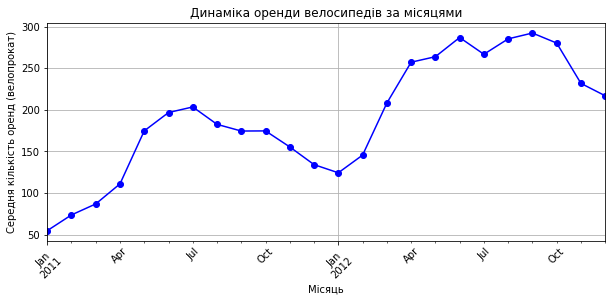

In [6]:
average_rent = df['count'].resample('M').mean()

average_rent.plot(
    figsize=(10,4),
    title=('Динаміка оренди велосипедів за місяцями'),
    xlabel=('Місяць'),
    ylabel=('Середня кількість оренд (велопрокат)'),
    marker='o',
    color='blue',
    grid=True,
    rot=45
);

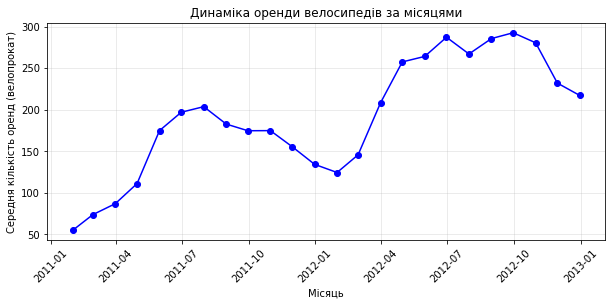

In [9]:
plt.figure(figsize=(10,4))

plt.plot(average_rent, color='blue', marker='o')
plt.title('Динаміка оренди велосипедів за місяцями')
plt.xlabel('Місяць')
plt.ylabel('Середня кількість оренд (велопрокат)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

Мені більше подобається Matplotlib, бо вісь дати краще чиається.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень продажі були стабільніші?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [4]:
days = [1, 2, 3, 4, 5, 6, 7] 
sales_week1 = [1349,1562,1600,1606,1510,959,822] 
sales_week2 = [1321,1263,1162,1406,1421,1248,1204] 

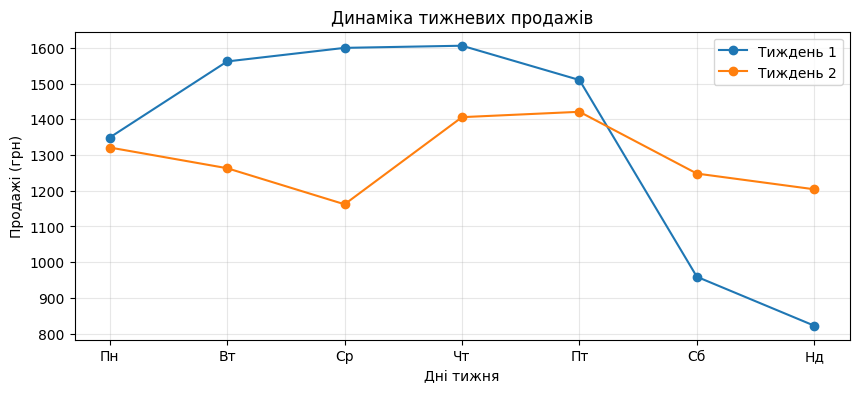

In [5]:
plt.figure(figsize=(10,4))

plt.plot(days, sales_week1, label='Тиждень 1', marker='o')
plt.plot(days, sales_week2, label='Тиждень 2', marker='o')
plt.title('Динаміка тижневих продажів')
plt.xlabel('Дні тижня')
plt.ylabel('Продажі (грн)')
plt.xticks(days, ['Пн','Вт','Ср','Чт','Пт','Сб','Нд'])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Порівняльна стабільність: Протягом другого тижня спостерігається більш рівномірна динаміка продажів. Натомість перший тиждень характеризується високою волатильністю (мінливістю).

Аналіз коливань: На першому тижні зафіксовано зростання у робочі дні, яке змінилося критичним спадом у вихідні (обсяги впали майже вдвічі). Саме цей розрив між буднями та вікендом створює ефект нестабільності на початку періоду.

In [6]:
import numpy as np
print(f'Week1: std={round(np.std(sales_week1),1)}, mean={np.mean(sales_week1)}, median={np.median(sales_week1)}, min={np.min(sales_week1)}, max={np.max(sales_week1)}')

print(f'Week2: std={round(np.std(sales_week2),1)}, mean={round(np.mean(sales_week2),1)}, median={np.median(sales_week2)}, min={np.min(sales_week2)}, max={np.max(sales_week2)}')

Week1: std=300.0, mean=1344.0, median=1510.0, min=822, max=1606
Week2: std=90.9, mean=1289.3, median=1263.0, min=1162, max=1421


In [7]:
metrics = {
    "mean":   [np.mean(sales_week1), np.mean(sales_week2)],
    "median": [np.median(sales_week1), np.median(sales_week2)],
    "std":    [np.std(sales_week1), np.std(sales_week2)],
    "min":    [np.min(sales_week1), np.min(sales_week2)],
    "max":    [np.max(sales_week1), np.max(sales_week2)],
    "range":  [np.max(sales_week1)-np.min(sales_week1), np.max(sales_week2)-np.min(sales_week2)]
}

print("Показник     Тиждень 1   Тиждень 2")
for k, (v1, v2) in metrics.items():
    print(f"{k:<10} {v1:>10.1f} {v2:>10.1f}")

Показник     Тиждень 1   Тиждень 2
mean           1344.0     1289.3
median         1510.0     1263.0
std             300.0       90.9
min             822.0     1162.0
max            1606.0     1421.0
range           784.0      259.0


## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

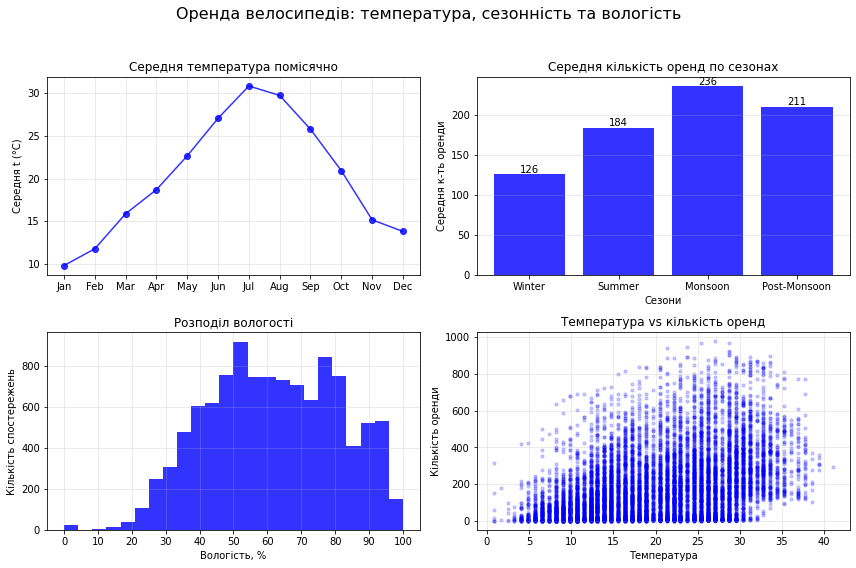

In [18]:
avg_temp_by_month = df.groupby(df.index.month)['temp'].mean()
avg_rent_by_quarter = df.groupby('weather_season_india')['count'].mean()

plt.figure(figsize=(12,8))

# Графік 1
plt.subplot(2, 2, 1)
plt.plot(avg_temp_by_month.index, avg_temp_by_month.values, color='blue', marker='o', alpha=0.8)
plt.title('Середня температура помісячно')
plt.ylabel('Середня t (°C)')
#plt.xticks(rotation=45)
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True, alpha=0.3)


# Графік 2
plt.subplot(2, 2, 2)
bars = plt.bar(avg_rent_by_quarter.index, avg_rent_by_quarter.values, color='blue', alpha=0.8)
plt.bar_label(bars, fmt='%.0f')
plt.title('Середня кількість оренд по сезонах')
plt.xlabel('Сезони')
plt.ylabel('Середня к-ть оренди')
plt.xticks(avg_rent_by_quarter.index, ['Winter','Summer','Monsoon','Post-Monsoon'])
plt.grid(True, axis='y', alpha=0.3)

# Графік 3
plt.subplot(2, 2, 3)
plt.hist(df['humidity'], bins=24, color='blue', alpha=0.8)
plt.title('Розподіл вологості')
plt.xlabel('Вологість, %')
plt.ylabel('Кількість спостережень')                
plt.xticks(range(0, 101, 10)) 
plt.grid(True, alpha=0.3)


# Графік 4
plt.subplot(2, 2, 4)
plt.scatter(df['temp'], df['count'], color='blue', s=10, alpha=0.2)
plt.title('Температура vs кількість оренд')
plt.xlabel('Температура')
plt.ylabel('Кількість оренди')
plt.grid(True, alpha=0.3)

# Заголовок всієї фігури 
plt.suptitle('Оренда велосипедів: температура, сезонність та вологість', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

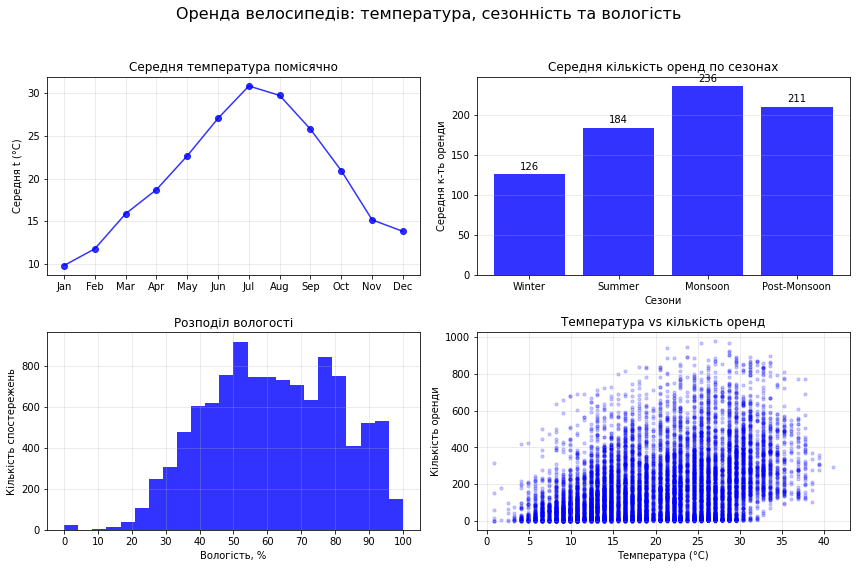

In [17]:
avg_temp_by_month = df.groupby(df.index.month)['temp'].mean()

order = ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']
avg_rent_by_quarter = df.groupby('weather_season_india_name')['count'].mean().reindex(order)

# 2x2 сітка графіків
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Графік 1
ax[0, 0].plot(avg_temp_by_month.index, avg_temp_by_month.values, color='blue', marker='o', alpha=0.8)
ax[0, 0].set_title('Середня температура помісячно')
ax[0, 0].set_ylabel('Середня t (°C)')
ax[0, 0].set_xticks(range(1, 13)) 
ax[0, 0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax[0, 0].grid(True, alpha=0.3)


# Графік 2
bars = ax[0, 1].bar(
    avg_rent_by_quarter.index.astype(str), 
    avg_rent_by_quarter.values, 
    color='blue', 
    alpha=0.8)
ax[0, 1].bar_label(bars, fmt='%.0f', padding=3)               
ax[0, 1].set_title('Середня кількість оренд по сезонах')
ax[0, 1].set_xlabel('Сезони')
ax[0, 1].set_ylabel('Середня к-ть оренди')
ax[0, 1].grid(True, axis='y', alpha=0.3)

# Графік 3
ax[1, 0].hist(df['humidity'], bins=24, color='blue', alpha=0.8)
ax[1, 0].set_title('Розподіл вологості')
ax[1, 0].set_xlabel('Вологість, %')
ax[1, 0].set_ylabel('Кількість спостережень')                
ax[1, 0].set_xticks(range(0, 101, 10)) 
ax[1, 0].grid(True, alpha=0.3)


# Графік 4
ax[1, 1].scatter(df['temp'], df['count'], color='blue', s=10, alpha=0.2)
ax[1, 1].set_title('Температура vs кількість оренд')
ax[1, 1].set_xlabel('Температура (°C)')
ax[1, 1].set_ylabel('Кількість оренди')
ax[1, 1].grid(True, alpha=0.3)

# Заголовок всієї фігури 
fig.suptitle('Оренда велосипедів: температура, сезонність та вологість', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Відмінність у побудові графіків підходами Subplot та Subplots відрізняється синтаксисом: 
- `plt.subplot()` додає підграфіки по одному і працює з “активною” віссю,
- `plt.subplots()` одразу створює фігуру та набір осей (fig, ax) і дозволяє керувати кожним графіком через ax.

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

In [20]:
import matplotlib.dates as mdates

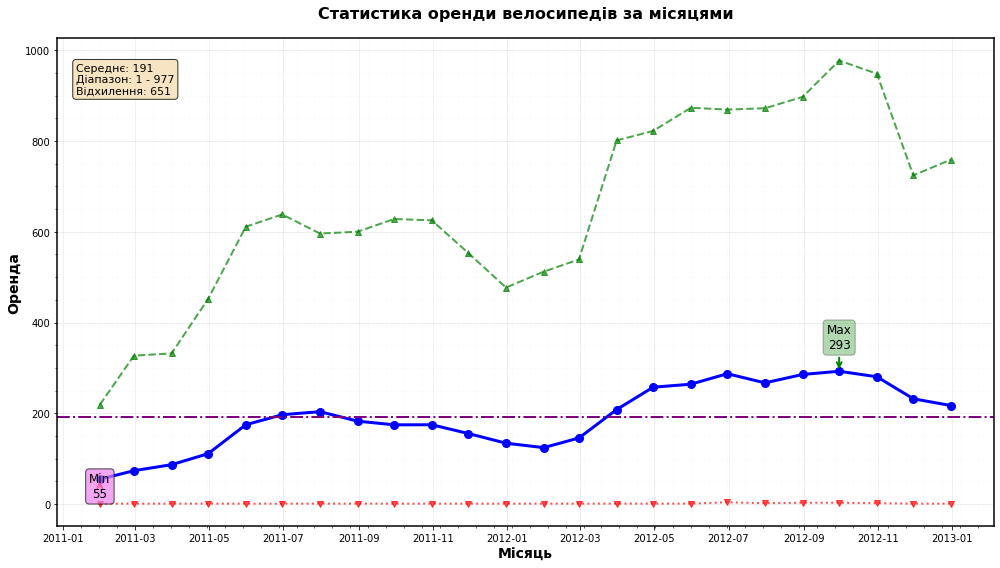

In [25]:
monthly_stats = df['count'].resample('M').agg(['mean', 'max', 'min'])

fig, ax = plt.subplots(figsize=(14, 8))


ax.plot(monthly_stats.index, monthly_stats['mean'], 'b-o', linewidth=3,
        label='Mean', markersize=8)
ax.plot(monthly_stats.index, monthly_stats['max'], 'g--^', linewidth=2,
        label='Max', markersize=6, alpha=0.7)
ax.plot(monthly_stats.index, monthly_stats['min'], 'r:v', linewidth=2,
        label='Min', markersize=6, alpha=0.7)


max_idx = monthly_stats['mean'].idxmax()
max_val = monthly_stats['mean'].max()
ax.annotate(f'Max\n{max_val:.0f}',
            xy=(max_idx, max_val), xytext=(max_idx, max_val + 50),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=12, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='green', alpha=0.3))

min_idx = monthly_stats['mean'].idxmin()
min_val = monthly_stats['mean'].min()
ax.annotate(f'Min\n{min_val:.0f}',
            xy=(min_idx, min_val), xytext=(min_idx, min_val - 40),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=12, ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='violet', alpha=0.7))


ax.set_xlabel('Місяць', fontsize=14, fontweight='bold')
ax.set_ylabel('Оренда', fontsize=14, fontweight='bold')
ax.set_title('Статистика оренди велосипедів за місяцями',
             fontsize=16, fontweight='bold', pad=20)


ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))      
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))     
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))      


ax.yaxis.set_minor_locator(plt.MultipleLocator(50))


overall_mean = monthly_stats['mean'].mean()
ax.axhline(y=overall_mean, color='purple', linestyle='-.', linewidth=2,
           label=f'Середнє за рік: {overall_mean:.0f}')


ax.minorticks_on()
ax.grid(True, which='major', linestyle='-', linewidth=0.8, alpha=0.25)
ax.grid(True, which='minor', linestyle=':', linewidth=0.6, alpha=0.15)


avg_mean = monthly_stats['mean'].mean()
global_min = monthly_stats['min'].min()
global_max = monthly_stats['max'].max()
avg_spread = (monthly_stats['max'] - monthly_stats['min']).mean()
textstr = (
    f"Середнє: {avg_mean:.0f}\n"
    f"Діапазон: {global_min:.0f} - {global_max:.0f}\n"
    f"Відхилення: {avg_spread:.0f}"
)
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)


for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()